In [5]:
# ============================================================
# 0. INTRO
# ============================================================
# Importamos las librerías necesarias

# Dataset de ejemplo incluido en scikit-learn (cáncer de mama)
from sklearn.datasets import load_breast_cancer

# Funciones para dividir datos y validar modelos
from sklearn.model_selection import train_test_split, cross_val_score

# Algoritmo de clasificación que vamos a usar
from sklearn.ensemble import RandomForestClassifier

# Métricas para evaluar el rendimiento del modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Herramienta para escalar (normalizar) las variables numéricas
from sklearn.preprocessing import StandardScaler

# Librerías para hacer gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías generales para cálculo numérico y manejo de datos
import numpy as np
import pandas as pd
import GEOparse

In [6]:
# ============================================================
# 1. CARGA Y EXPLORACIÓN INICIAL
# ============================================================

# Cargamos el dataset 
gse = GEOparse.get_GEO("GSE2034", destdir="./data")

# Extraemos la matriz de variables (X) y la variable objetivo (y)
# Sin interpretar aún su significado
X = data.data
y = data.target

# Intentamos obtener nombres de variables si existen
feature_names = getattr(data, "feature_names", None)


# ============================================================
# INSPECCIÓN AUTOMÁTICA DEL DATASET
# ============================================================

print("=== BASIC DATASET INFORMATION ===")

# Número de muestras y variables
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

# Valores únicos de la variable objetivo
print("\nUnique target values:")
print(np.unique(y))

# Si el dataset incluye nombres de clases, los mostramos
if hasattr(data, "target_names"):
    print("\nTarget names (if provided):")
    print(data.target_names)

# Conteo de muestras por clase
print("\nSamples per class:")
print(np.bincount(y))


# ============================================================
# CONVERSIÓN A TABLA PARA INSPECCIÓN HUMANA
# ============================================================

# Creamos un DataFrame para visualizar mejor los datos
if feature_names is not None:
    df = pd.DataFrame(X, columns=feature_names)
else:
    df = pd.DataFrame(X)

# Añadimos la variable objetivo
df["target"] = y

print("\nFirst rows of the dataset:")
display(df.head())


# ============================================================
# INFORMACIÓN GENERAL Y ESTADÍSTICAS
# ============================================================

print("\nDataset info:")
df.info()

print("\nStatistical summary:")
display(df.describe())


# ============================================================
# DESCRIPCIÓN DEL DATASET (SI EXISTE)
# ============================================================

if hasattr(data, "DESCR"):
    print("\nDataset description:")
    print(data.DESCR[:1000])  # solo el inicio

=== BASIC DATASET INFORMATION ===
Number of samples: 569
Number of features: 30

Unique target values:
[0 1]

Target names (if provided):
['malignant' 'benign']

Samples per class:
[212 357]

First rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness 

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Dataset description:
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is

In [7]:
# ============================================================
# 2. DIVISIÓN EN ENTRENAMIENTO Y PRUEBA
# ============================================================

# Separamos los datos en dos partes:
# - Entrenamiento: para construir el modelo
# - Test: para evaluar con datos "nuevos"
# IMPORTANTE: la división se hace ANTES de cualquier transformación

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [8]:
# ============================================================
# 3. ESCALADO DE VARIABLES (SIN FUGA DE INFORMACIÓN)
# ============================================================

# Ajustamos el escalador SOLO con los datos de entrenamiento
# y lo aplicamos al conjunto de test

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  # aprende del train
X_test = scaler.transform(X_test)        # aplica al test


In [9]:
# ============================================================
# 4. ENTRENAMIENTO DEL MODELO
# ============================================================

# Creamos un modelo Random Forest
# Es un conjunto de muchos árboles de decisión

model = RandomForestClassifier(
    n_estimators=100,     # número de árboles
    max_depth=10,         # profundidad máxima de cada árbol
    min_samples_split=5,  # mínimo de muestras para dividir un nodo
    random_state=42       # reproducibilidad
)

# Entrenamos el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)

In [10]:
# ============================================================
# 5. VALIDACIÓN CRUZADA
# ============================================================

# La validación cruzada entrena el modelo varias veces
# con distintas particiones de los datos de entrenamiento

cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean():.4f}")

Cross-validation scores: [0.96703297 0.94505495 0.97802198 0.95604396 0.94505495]
Mean CV score: 0.9582


In [11]:
# ============================================================
# 6. PREDICCIÓN Y EVALUACIÓN
# ============================================================

# El modelo predice las etiquetas del conjunto de prueba
y_pred = model.predict(X_test)

# Accuracy = proporción de aciertos totales
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Informe detallado con varias métricas por clase
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Text(0.5, 1.0, 'Confusion Matrix')

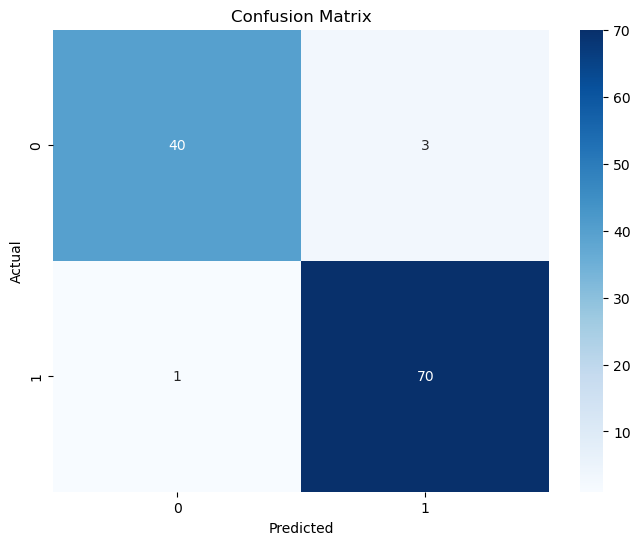

In [12]:
# ============================================================
# 7. MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

# Usamos etiquetas automáticas (no asumimos nombres concretos)
class_labels = np.unique(y)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')


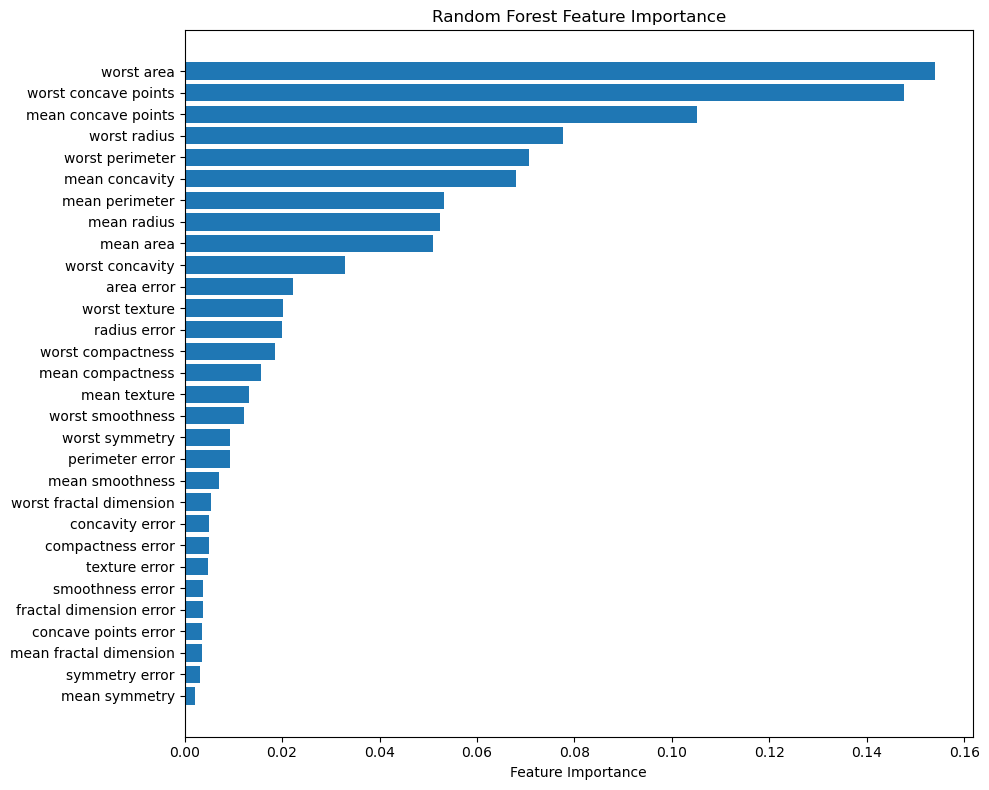

In [13]:
# ============================================================
# 8. IMPORTANCIA DE VARIABLES
# ============================================================

feature_importance = model.feature_importances_

sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 8))

plt.barh(
    range(len(sorted_idx)),
    feature_importance[sorted_idx],
    align='center'
)

# Solo mostramos nombres si existen
if feature_names is not None:
    plt.yticks(
        range(len(sorted_idx)),
        [feature_names[i] for i in sorted_idx]
    )

plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()

In [14]:
# ============================================================
# 9. SELECCIÓN DE VARIABLES BASADA EN IMPORTANCIA
# ============================================================

# Número de variables que queremos conservar
# (puedes cambiarlo para experimentar)
top_n = 10

# Índices de las variables ordenadas por importancia (descendente)
important_indices = np.argsort(model.feature_importances_)[::-1]

# Seleccionamos las N más importantes
selected_indices = important_indices[:top_n]

print(f"Selected top {top_n} features (indices):")
print(selected_indices)

# Si existen nombres de variables, los mostramos
if feature_names is not None:
    print("\nSelected feature names:")
    for i in selected_indices:
        print(feature_names[i])

Selected top 10 features (indices):
[23 27  7 20 22  6  2  0  3 26]

Selected feature names:
worst area
worst concave points
mean concave points
worst radius
worst perimeter
mean concavity
mean perimeter
mean radius
mean area
worst concavity


In [15]:
# ============================================================
# 10. CREAR NUEVOS DATOS SOLO CON LAS VARIABLES SELECCIONADAS
# ============================================================

X_train_sel = X_train[:, selected_indices]
X_test_sel = X_test[:, selected_indices]

print("\nOriginal number of features:", X_train.shape[1])
print("Selected number of features:", X_train_sel.shape[1])


Original number of features: 30
Selected number of features: 10


In [16]:
# ============================================================
# 11. ENTRENAMIENTO CON VARIABLES SELECCIONADAS
# ============================================================

model_sel = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model_sel.fit(X_train_sel, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, random_state=42)

In [17]:
# ============================================================
# 12. EVALUACIÓN DEL MODELO REDUCIDO
# ============================================================

y_pred_sel = model_sel.predict(X_test_sel)

print("\n=== RESULTS WITH SELECTED FEATURES ===")

print(f"Accuracy: {accuracy_score(y_test, y_pred_sel):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_sel))


=== RESULTS WITH SELECTED FEATURES ===
Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

